# California Housing - EDA and Preprocessing Pipeline

This notebook builds a reproducible preprocessing workflow for the California Housing dataset.

Checklist covered in this notebook:
- Median imputation for `total_bedrooms`
- Ratio features (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`) + optional ratio scan
- One-hot encoding for `ocean_proximity`
- Feature scaling (StandardScaler)
- Outlier handling via 1st/99th percentiles (row removal)
- Stratified train-test split using income categories
- End-to-end preprocessing pipeline
- Log transformation of skewed features
- Correlation analysis
- Feature importance preview
- Versioned outputs in `data/processed` (tabular splits + transformed matrices + metadata)

> Leakage rule: all fit operations are learned on the training split only.

In [1]:
from __future__ import annotations

from datetime import datetime, UTC
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)

RAW_PATH = Path("../data/raw/housing.csv")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "median_house_value"
CAT_COL = "ocean_proximity"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df_raw = pd.read_csv(RAW_PATH)
print(f"Loaded raw dataset from {RAW_PATH.resolve()}")
print(f"Shape: {df_raw.shape}")

Loaded raw dataset from /Users/niki/dev/02 - OPIT/2 - Second Year/Machine Learning/California Housing Prices/data/raw/housing.csv
Shape: (20640, 10)


In [2]:
# Basic overview
print("\nData types:")
print(df_raw.dtypes)

print("\nFirst rows:")
display(df_raw.head())

print("\nSummary statistics:")
display(df_raw.describe(include="all"))


Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

First rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Summary statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


In [3]:
# Data quality checks
missing_counts = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df_raw) * 100).round(3)
missing_table = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})

duplicate_count = int(df_raw.duplicated().sum())

print(f"Duplicate rows: {duplicate_count}")
print("\nMissing values:")
display(missing_table[missing_table["missing_count"] > 0])

print("\nCategory distribution for ocean_proximity:")
display(df_raw[CAT_COL].value_counts(dropna=False))

Duplicate rows: 0

Missing values:


,missing_count,missing_pct
total_bedrooms,207,1.003



Category distribution for ocean_proximity:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Correlation with target:


,corr_with_target
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


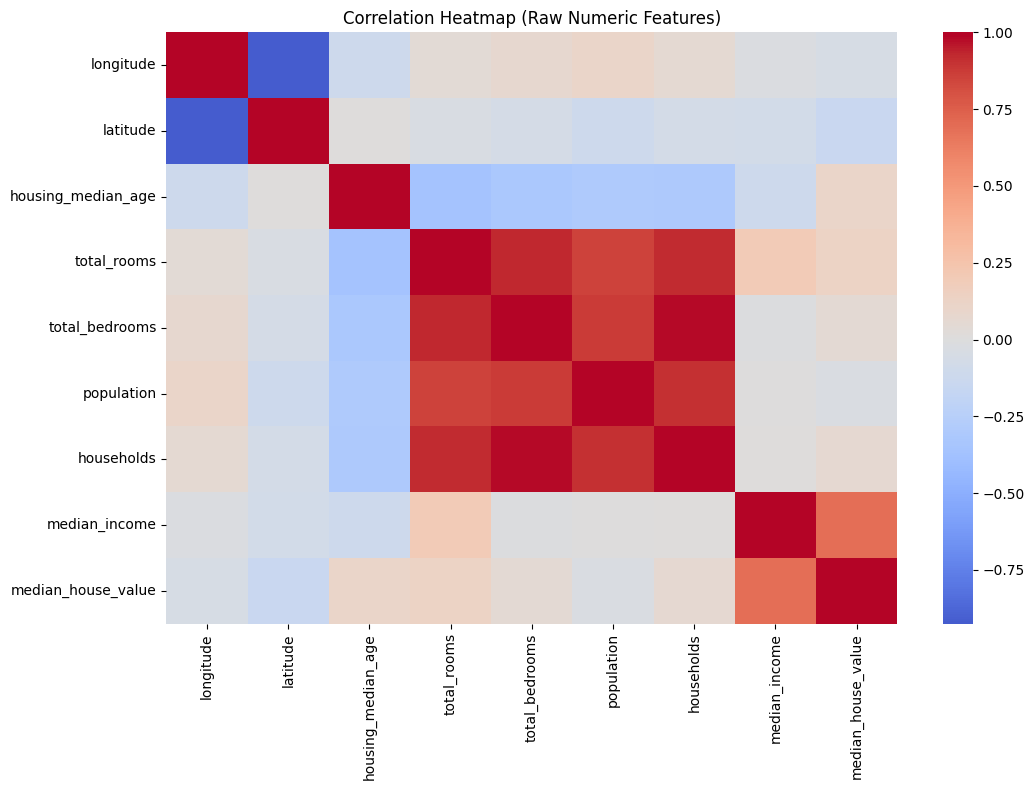

In [4]:
# Correlation analysis (numeric only)
numeric_cols_all = df_raw.select_dtypes(include=[np.number]).columns.tolist()

corr = df_raw[numeric_cols_all].corr(numeric_only=True)

target_corr = corr[TARGET].sort_values(ascending=False)
print("Correlation with target:")
display(target_corr.to_frame(name="corr_with_target"))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Raw Numeric Features)")
plt.tight_layout()
plt.show()

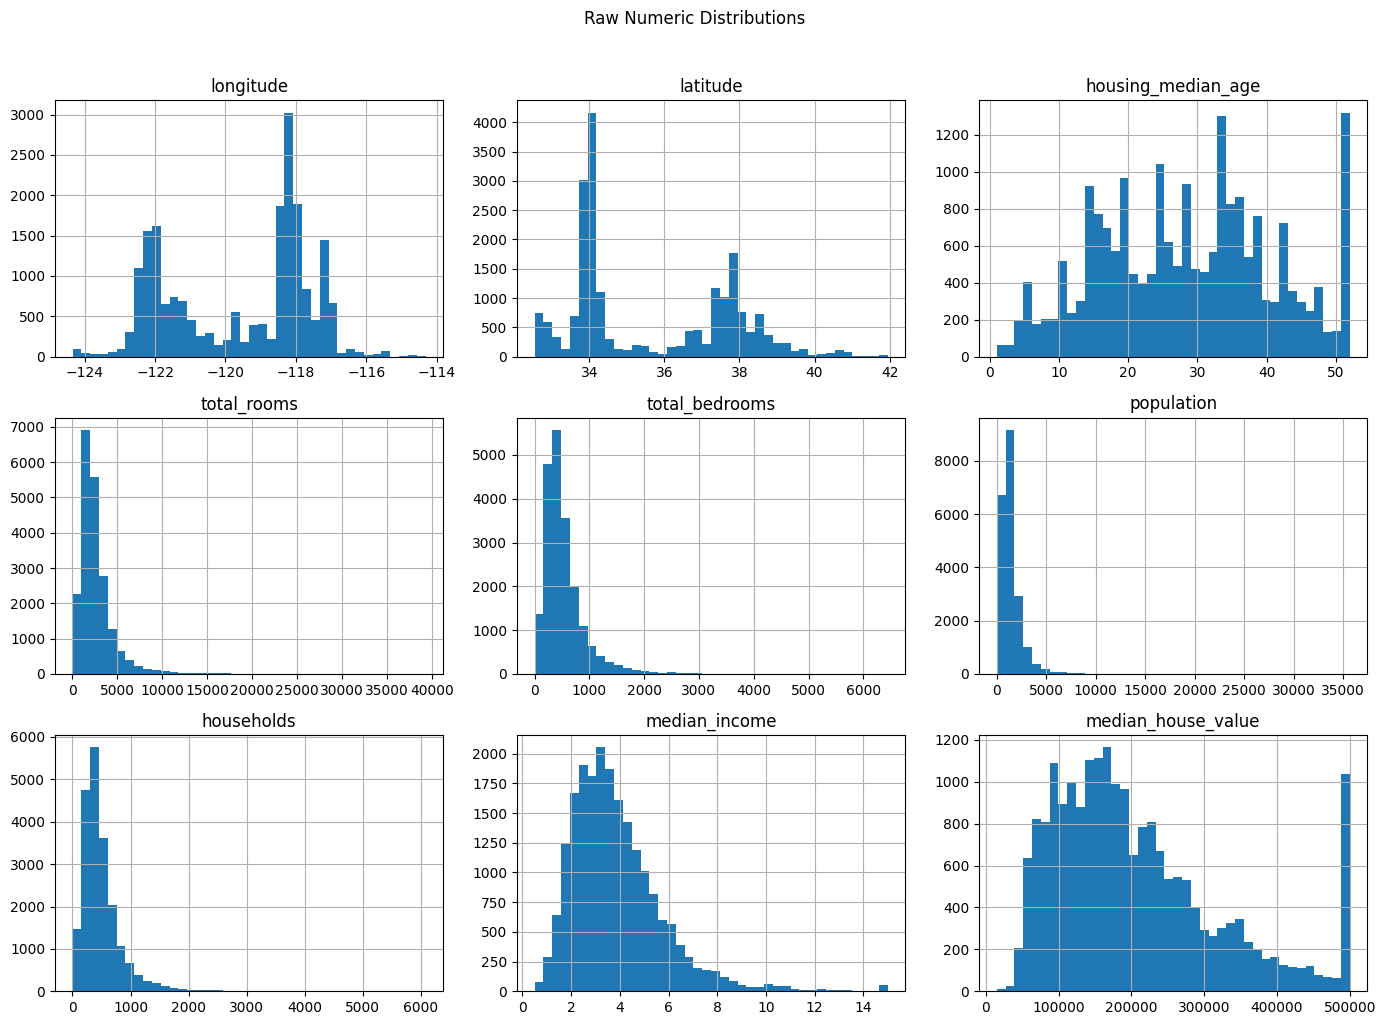

Skewness (raw numeric):


,skewness
population,4.935858
total_rooms,4.147343
total_bedrooms,3.459546
households,3.410438
median_income,1.646657
median_house_value,0.977763
latitude,0.465953
housing_median_age,0.060331
longitude,-0.297801


In [5]:
# Distribution and skewness scan (raw numeric features)
fig = df_raw[numeric_cols_all].hist(bins=40, figsize=(14, 10))
plt.suptitle("Raw Numeric Distributions", y=1.02)
plt.tight_layout()
plt.show()

skewness_raw = df_raw[numeric_cols_all].skew(numeric_only=True).sort_values(ascending=False)
print("Skewness (raw numeric):")
display(skewness_raw.to_frame(name="skewness"))

In [6]:
# Stratified train-test split by income categories
split_df = df_raw.copy()
split_df["income_cat"] = pd.qcut(split_df["median_income"], q=5, labels=["very_low", "low", "mid", "high", "very_high"])

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, test_idx in splitter.split(split_df, split_df["income_cat"]):
    train_df = split_df.iloc[train_idx].copy()
    test_df = split_df.iloc[test_idx].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

dist_check = pd.DataFrame(
    {
        "full": split_df["income_cat"].value_counts(normalize=True).sort_index(),
        "train": train_df["income_cat"].value_counts(normalize=True).sort_index(),
        "test": test_df["income_cat"].value_counts(normalize=True).sort_index(),
    }
)
print("Income category distribution check:")
display(dist_check)

# Remove helper stratification column from modeling frames.
train_df = train_df.drop(columns=["income_cat"])
test_df = test_df.drop(columns=["income_cat"])

X_train = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()
X_test = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()

Train shape: (16512, 11)
Test shape: (4128, 11)
Income category distribution check:


,full,train,test
income_cat,,,
very_low,0.200097,0.200097,0.200097
low,0.200145,0.200157,0.200097
mid,0.199758,0.199734,0.199855
high,0.200000,0.200036,0.199855
very_high,0.200000,0.199976,0.200097


## Feature Engineering + Outlier Policy

This section defines reusable transformers for:
- Median imputation of `total_bedrooms`
- Ratio features
- Log transforms for skewed numeric features
- Outlier handling at 1st/99th percentiles (train-derived thresholds, row removal)

In [7]:
class RatioFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_extra_ratios: bool = True):
        self.add_extra_ratios = add_extra_ratios

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-9

        X["rooms_per_household"] = X["total_rooms"] / (X["households"] + eps)
        X["bedrooms_per_room"] = X["total_bedrooms"] / (X["total_rooms"] + eps)
        X["population_per_household"] = X["population"] / (X["households"] + eps)

        if self.add_extra_ratios:
            # Optional additional ratios to test for signal strength.
            X["rooms_per_person"] = X["total_rooms"] / (X["population"] + eps)
            X["bedrooms_per_household"] = X["total_bedrooms"] / (X["households"] + eps)

        return X


# Median imputation value must be learned on train only.
bedrooms_median = X_train["total_bedrooms"].median()
X_train["total_bedrooms"] = X_train["total_bedrooms"].fillna(bedrooms_median)
X_test["total_bedrooms"] = X_test["total_bedrooms"].fillna(bedrooms_median)

print(f"Median used for total_bedrooms imputation: {bedrooms_median:.3f}")

ratio_adder = RatioFeatureAdder(add_extra_ratios=True)
X_train_ratio = ratio_adder.fit_transform(X_train)
X_test_ratio = ratio_adder.transform(X_test)

print("Ratio columns added:")
ratio_cols = [
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "rooms_per_person",
    "bedrooms_per_household",
]
print(ratio_cols)

display(X_train_ratio[ratio_cols].describe().T)

Median used for total_bedrooms imputation: 433.000
Ratio columns added:
['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'rooms_per_person', 'bedrooms_per_household']


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,16512.0,5.435615,2.594818,0.846154,4.443526,5.227722,6.052096,141.909091
bedrooms_per_room,16512.0,0.213523,0.065591,0.042174,0.175075,0.202969,0.239718,2.811688
population_per_household,16512.0,3.100568,11.583889,0.692308,2.432164,2.820312,3.287998,1243.333333
rooms_per_person,16512.0,1.977899,1.199003,0.002547,1.520262,1.937500,2.294979,55.222222
bedrooms_per_household,16512.0,1.101383,0.552939,0.281718,1.004963,1.048780,1.099480,34.066667


In [8]:
# Identify skewed numeric features on train and apply log1p where appropriate.
# Exclude coordinates and age from log transform for interpretability.
log_exclude = {"longitude", "latitude", "housing_median_age"}
train_numeric_cols = X_train_ratio.select_dtypes(include=[np.number]).columns.tolist()
skewness_train = X_train_ratio[train_numeric_cols].skew(numeric_only=True)

log_features = [
    col
    for col in train_numeric_cols
    if (skewness_train[col] > 0.75) and (col not in log_exclude)
]

X_train_fe = X_train_ratio.copy()
X_test_fe = X_test_ratio.copy()

for col in log_features:
    min_train = X_train_fe[col].min()
    shift = 0.0 if min_train > -1 else abs(min_train) + 1.0
    X_train_fe[col] = np.log1p(X_train_fe[col] + shift)
    X_test_fe[col] = np.log1p(X_test_fe[col] + shift)

print("Log-transformed features:")
print(log_features if log_features else "None selected")

Log-transformed features:
['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'rooms_per_person', 'bedrooms_per_household']


In [9]:
# Outlier handling: remove rows outside 1st/99th percentile bounds using train-only thresholds.
outlier_numeric_cols = [c for c in X_train_fe.select_dtypes(include=[np.number]).columns if c != TARGET]

bounds = {}
train_mask = pd.Series(True, index=X_train_fe.index)
test_mask = pd.Series(True, index=X_test_fe.index)

for col in outlier_numeric_cols:
    low, high = X_train_fe[col].quantile([0.01, 0.99])
    bounds[col] = {"p01": float(low), "p99": float(high)}
    train_mask &= X_train_fe[col].between(low, high, inclusive="both")
    test_mask &= X_test_fe[col].between(low, high, inclusive="both")

X_train_clean = X_train_fe.loc[train_mask].copy()
y_train_clean = y_train.loc[train_mask].copy()
X_test_clean = X_test_fe.loc[test_mask].copy()
y_test_clean = y_test.loc[test_mask].copy()

print(f"Train rows before/after outlier removal: {len(X_train_fe)} -> {len(X_train_clean)}")
print(f"Test rows before/after outlier removal: {len(X_test_fe)} -> {len(X_test_clean)}")

Train rows before/after outlier removal: 16512 -> 14425
Test rows before/after outlier removal: 4128 -> 3575


## Preprocessing Pipeline

Build an end-to-end `ColumnTransformer` with:
- Numeric branch: StandardScaler
- Categorical branch: OneHotEncoder for `ocean_proximity`

All fitting is done on training data only.

In [10]:
numeric_features = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
if CAT_COL in numeric_features:
    numeric_features.remove(CAT_COL)

categorical_features = [CAT_COL]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("scaler", StandardScaler())]), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    )
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

X_train_processed = preprocessor.fit_transform(X_train_clean)
X_test_processed = preprocessor.transform(X_test_clean)

num_feature_names = numeric_features
cat_feature_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train_clean.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test_clean.index)

print(f"Processed train matrix: {X_train_processed_df.shape}")
print(f"Processed test matrix: {X_test_processed_df.shape}")
print("One-hot columns:")
print(cat_feature_names)

Processed train matrix: (14425, 18)
Processed test matrix: (3575, 18)
One-hot columns:
['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [11]:
# Correlation analysis after feature engineering (before scaling for readability)
engineered_train = X_train_clean.copy()
engineered_train[TARGET] = y_train_clean

corr_engineered = engineered_train.select_dtypes(include=[np.number]).corr(numeric_only=True)
target_corr_engineered = corr_engineered[TARGET].sort_values(ascending=False)

print("Top correlations with target after engineering:")
display(target_corr_engineered.to_frame(name="corr_with_target").head(12))
display(target_corr_engineered.to_frame(name="corr_with_target").tail(12))

Top correlations with target after engineering:


,corr_with_target
median_house_value,1.000000
median_income,0.668780
rooms_per_person,0.453828
rooms_per_household,0.291053
total_rooms,0.183838
housing_median_age,0.111604
households,0.085344
total_bedrooms,0.070796
population,-0.042773
longitude,-0.051681


,corr_with_target
rooms_per_person,0.453828
rooms_per_household,0.291053
total_rooms,0.183838
housing_median_age,0.111604
households,0.085344
total_bedrooms,0.070796
population,-0.042773
longitude,-0.051681
bedrooms_per_household,-0.092788
latitude,-0.138468


In [12]:
# Feature importance preview (EDA only)
rf = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train_processed_df, y_train_clean)

importance_df = (
    pd.DataFrame({"feature": all_feature_names, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 feature importances (EDA preview):")
display(importance_df.head(15))

Top 15 feature importances (EDA preview):


,feature,importance
0,median_income,0.442914
1,ocean_proximity_INLAND,0.145166
2,population_per_household,0.119441
3,longitude,0.057039
4,latitude,0.050365
5,housing_median_age,0.047616
6,rooms_per_person,0.043117
7,bedrooms_per_household,0.018807
8,bedrooms_per_room,0.018669
9,rooms_per_household,0.015645


In [13]:
# Save versioned processed outputs
train_tabular = X_train_clean.copy()
train_tabular[TARGET] = y_train_clean

test_tabular = X_test_clean.copy()
test_tabular[TARGET] = y_test_clean

train_tabular_path = PROCESSED_DIR / "train_engineered.csv"
test_tabular_path = PROCESSED_DIR / "test_engineered.csv"
X_train_processed_path = PROCESSED_DIR / "X_train_processed.csv"
X_test_processed_path = PROCESSED_DIR / "X_test_processed.csv"
y_train_path = PROCESSED_DIR / "y_train.csv"
y_test_path = PROCESSED_DIR / "y_test.csv"
npz_path = PROCESSED_DIR / "processed_matrices.npz"
metadata_path = PROCESSED_DIR / "metadata.json"

train_tabular.to_csv(train_tabular_path, index=False)
test_tabular.to_csv(test_tabular_path, index=False)
X_train_processed_df.to_csv(X_train_processed_path, index=False)
X_test_processed_df.to_csv(X_test_processed_path, index=False)
y_train_clean.to_csv(y_train_path, index=False)
y_test_clean.to_csv(y_test_path, index=False)

np.savez_compressed(
    npz_path,
    X_train=X_train_processed,
    X_test=X_test_processed,
    y_train=y_train_clean.to_numpy(),
    y_test=y_test_clean.to_numpy(),
)

metadata = {
    "run_date_utc": datetime.now(UTC).isoformat(),
    "seed": SEED,
    "raw_data": str(RAW_PATH),
    "target": TARGET,
    "stratification": {
        "column": "median_income",
        "method": "pd.qcut",
        "bins": ["very_low", "low", "mid", "high", "very_high"],
        "test_size": 0.2,
    },
    "imputation": {"column": "total_bedrooms", "strategy": "median", "value": float(bedrooms_median)},
    "ratio_features": ratio_cols,
    "log_features": log_features,
    "outlier_policy": {
        "method": "row_removal",
        "bounds": "1st-99th percentile",
        "thresholds_train": bounds,
        "rows": {
            "train_before": int(len(X_train_fe)),
            "train_after": int(len(X_train_clean)),
            "test_before": int(len(X_test_fe)),
            "test_after": int(len(X_test_clean)),
        },
    },
    "encoding": {"column": CAT_COL, "method": "one_hot", "columns": cat_feature_names},
    "scaling": {"method": "StandardScaler", "numeric_features": numeric_features},
    "artifacts": {
        "train_engineered": str(train_tabular_path),
        "test_engineered": str(test_tabular_path),
        "X_train_processed_csv": str(X_train_processed_path),
        "X_test_processed_csv": str(X_test_processed_path),
        "y_train_csv": str(y_train_path),
        "y_test_csv": str(y_test_path),
        "processed_matrices_npz": str(npz_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts:")
for artifact in [
    train_tabular_path,
    test_tabular_path,
    X_train_processed_path,
    X_test_processed_path,
    y_train_path,
    y_test_path,
    npz_path,
    metadata_path,
]:
    print(f"- {artifact}")

Saved artifacts:
- ../data/processed/train_engineered.csv
- ../data/processed/test_engineered.csv
- ../data/processed/X_train_processed.csv
- ../data/processed/X_test_processed.csv
- ../data/processed/y_train.csv
- ../data/processed/y_test.csv
- ../data/processed/processed_matrices.npz
- ../data/processed/metadata.json


In [14]:
# Validation checks and run summary
assert X_train_processed_df.isna().sum().sum() == 0, "Train processed matrix contains NaNs"
assert X_test_processed_df.isna().sum().sum() == 0, "Test processed matrix contains NaNs"
assert len(X_train_processed_df) == len(y_train_clean), "Train X/y misalignment"
assert len(X_test_processed_df) == len(y_test_clean), "Test X/y misalignment"

required_ratios = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
missing_ratios = [c for c in required_ratios if c not in X_train_clean.columns]
assert not missing_ratios, f"Missing required ratio features: {missing_ratios}"

print("All validation checks passed.")
print(f"Train rows used: {len(X_train_clean)}")
print(f"Test rows used: {len(X_test_clean)}")
print(f"Final feature count after preprocessing: {X_train_processed_df.shape[1]}")

All validation checks passed.
Train rows used: 14425
Test rows used: 3575
Final feature count after preprocessing: 18
